# Importing Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

---

# 1. Load Dataset

In [25]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("Sport_car_price.csv")
df.head(10)

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
5,BMW,M8,2022,4.4,617,553,3.1,"130,000"
6,Mercedes-Benz,AMG GT,2021,4,523,494,3.8,"118,500"
7,Chevrolet,Corvette,2021,6.2,490,465,2.8,"59,900"
8,Ford,Mustang Shelby GT500,2022,5.2,760,625,3.5,"81,000"
9,Nissan,GT-R Nismo,2021,3.8,600,481,2.5,"212,000"


In [41]:
# Cleaning the dataset: Removing symbols and converting strings to numbers
cols_to_fix = ['Horsepower', 'Torque (lb-ft)', '0-60 MPH Time (seconds)', 'Price (in USD)', 'Engine Size (L)']

for col in cols_to_fix:
    # Remove $, commas, and units, then convert to numeric
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[$,+]', '', regex=True).str.replace(',', ''), errors='coerce')

# Re-defining numeric columns now that the data is fixed
numeric_c = df.select_dtypes(include=np.number).columns
print("Updated numeric columns:", numeric_c.tolist())

Updated numeric columns: ['Year', 'Engine Size (L)', 'Horsepower', 'Torque (lb-ft)', '0-60 MPH Time (seconds)', 'Price (in USD)']


## 2. Data Quality Assessment
### 2.1 Check Data Types

In [42]:
df.dtypes

Car Make                    object
Car Model                   object
Year                         int64
Engine Size (L)            float64
Horsepower                   int64
Torque (lb-ft)             float64
0-60 MPH Time (seconds)    float64
Price (in USD)               int64
dtype: object

In [43]:
df.shape

(1007, 8)

### 2.2 Convert Incorrect Data Types

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Car Make                 1007 non-null   object 
 1   Car Model                1007 non-null   object 
 2   Year                     1007 non-null   int64  
 3   Engine Size (L)          948 non-null    float64
 4   Horsepower               1007 non-null   int64  
 5   Torque (lb-ft)           1003 non-null   float64
 6   0-60 MPH Time (seconds)  1006 non-null   float64
 7   Price (in USD)           1007 non-null   int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 63.1+ KB


In [7]:
df.describe()

,Year
count,1007.000000
mean,2021.201589
std,2.019802
min,1965.000000
25%,2021.000000
50%,2021.000000
75%,2022.000000
max,2023.000000


In [45]:
df.isnull().sum()

Car Make                    0
Car Model                   0
Year                        0
Engine Size (L)            59
Horsepower                  0
Torque (lb-ft)              4
0-60 MPH Time (seconds)     1
Price (in USD)              0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(292)

# 3. Handling Missing Values

In [47]:
numeric_c = df.select_dtypes(include=np.number).columns
df[numeric_c].fillna(df[numeric_c].median())

,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,2022,3.0,379,331.0,4.00,101200
1,2021,5.2,630,443.0,2.80,274390
2,2022,3.9,661,561.0,3.00,333750
3,2022,5.2,562,406.0,3.20,142700
4,2021,4.0,710,568.0,2.70,298000
...,...,...,...,...,...,...
1002,2022,5.0,1280,1106.0,2.50,3000000
1003,2021,4.0,1972,1254.0,2.00,2000000
1004,2021,4.0,789,590.0,2.70,1000000
1005,2021,6.0,764,738.0,3.00,2600000


In [48]:
print(f"Remainig missing values : {df.isnull().sum().sum() }")

Remainig missing values : 64


# 4. Handling Outliers

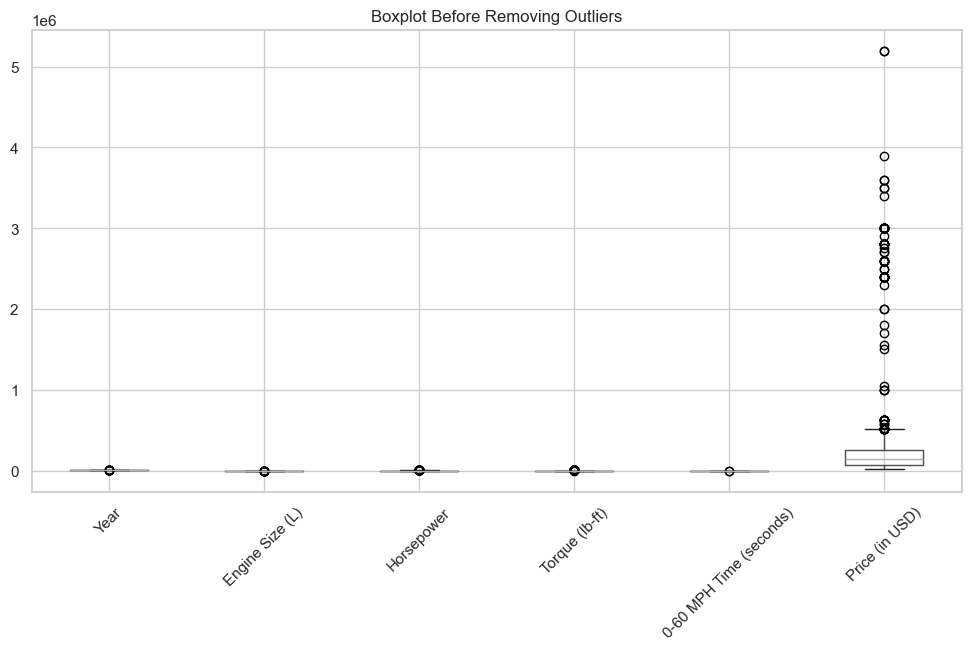

In [49]:
plt.figure(figsize=(12,6))
df[numeric_c].boxplot(rot=45)
plt.title("Boxplot Before Removing Outliers")
plt.show()

In [50]:

Q1 = df['Price (in USD)'].quantile(0.25)
Q3 = df['Price (in USD)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR 

df_no_outliers = df[(df['Price (in USD)'] >= lower_bound) & (df['Price (in USD)'] <= upper_bound)].copy()

print(f"Original shape: {df.shape}")
print(f"Shape after removing price outliers: {df_no_outliers.shape}")

Original shape: (1007, 8)
Shape after removing price outliers: (889, 8)


In [51]:
df_no_outliers = df[~((df[numeric_c] < lower_bound) | (df[numeric_c] > upper_bound)).any(axis=1)]
df_no_outliers.shape

(889, 8)

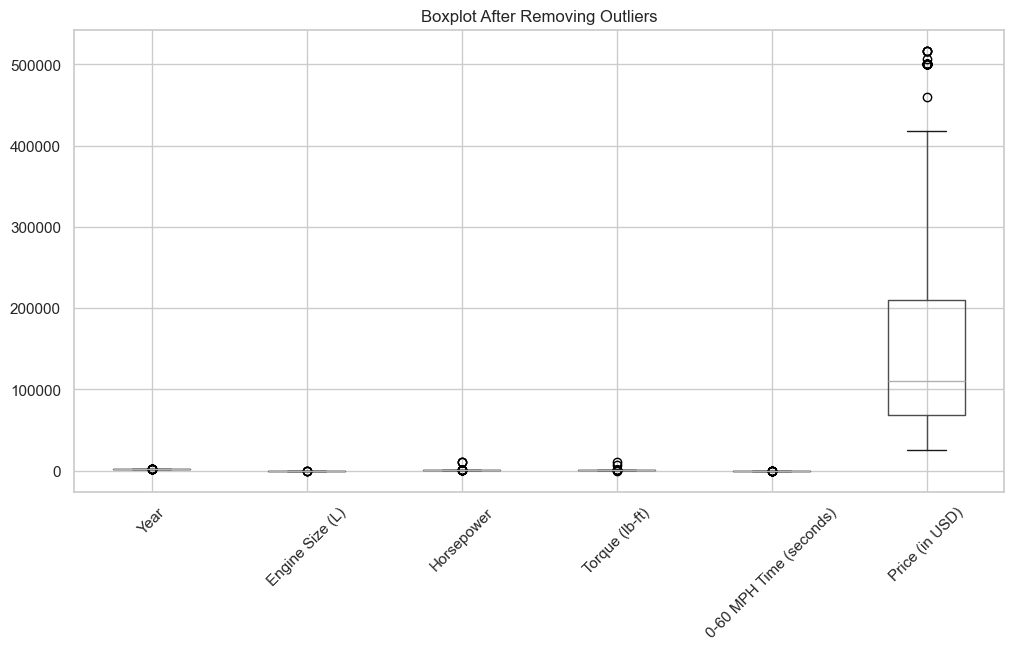

In [52]:
plt.figure(figsize=(12,6))
df_no_outliers[numeric_c].boxplot(rot=45)
plt.title("Boxplot After Removing Outliers")
plt.show()

# 5. Data Transformation - Normalization

### Min-Max Scaling

In [54]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

minmax_scaler = MinMaxScaler()

df_minmax = df_no_outliers.copy()
df_minmax[numeric_c] = minmax_scaler.fit_transform(df_minmax[numeric_c])

df_minmax.head() 

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,0.888889,0.357143,0.020165,0.0331,0.456522,0.154878
1,Lamborghini,Huracan,0.777778,0.619048,0.045728,0.0443,0.195652,0.506890
2,Ferrari,488 GTB,0.888889,0.464286,0.048885,0.0561,0.239130,0.627541
3,Audi,R8,0.888889,0.619048,0.038802,0.0406,0.282609,0.239228
4,McLaren,720S,0.777778,0.476190,0.053875,0.0568,0.173913,0.554878


### Z-Score Normalization

In [37]:
standard_scaler = StandardScaler()

df_zscore = df_no_outliers.copy()
df_zscore[numeric_c] = standard_scaler.fit_transform(df_zscore[numeric_c])

df_zscore.head()

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,1.174500,3,379,331,4,"101,200"
1,Lamborghini,Huracan,-0.684339,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,1.174500,3.9,661,561,3,"333,750"
3,Audi,R8,1.174500,5.2,562,406,3.2,"142,700"
4,McLaren,720S,-0.684339,4,710,568,2.7,"298,000"


# 6. Data Reduction - PCA

### Correlation before PCA

In [38]:
corr_matrix = df_zscore[numeric_c].corr()
corr_matrix

,Year
Year,1.0


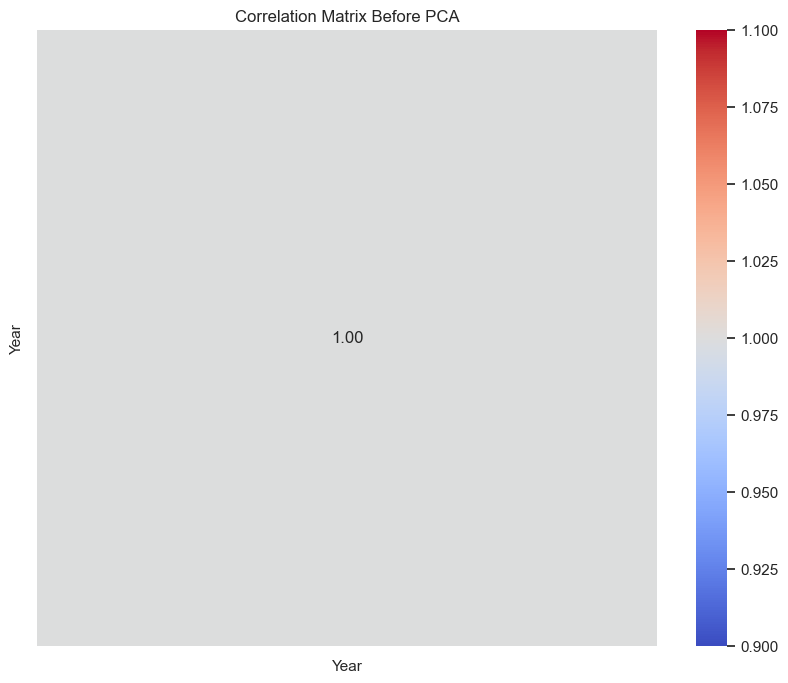

In [39]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Before PCA")
plt.show()

In [22]:
pca = PCA()
pca.fit(df_zscore[numeric_c])
explained_variance = pca.explained_variance_ratio_
explained_variance

array([1.])

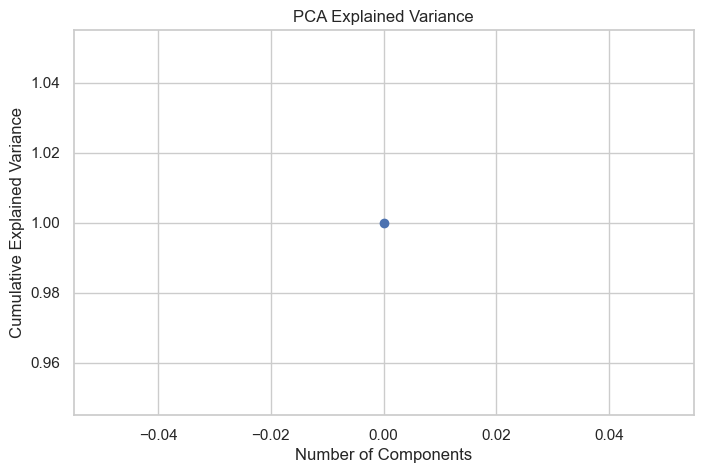

In [40]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()